In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA


### **Giai Đoạn 1: Đọc Dữ Liệu và Khám Phá Cơ Bản**
- Đọc file CSV từ `marketing_campaign.csv` (định dạng: tab-separated)
- Hiển thị kích thước dataset (số hàng, số cột)
- Kiểm tra thông tin cột (tên, kiểu dữ liệu, số lượng giá trị null)
- Xem mẫu dữ liệu đầu tiên
- Đếm bản ghi trùng lặp
- Kiểm tra giá trị thiếu trong mỗi cột

In [ ]:
# Đọc file CSV
df = pd.read_csv(r"C:\Users\This MC\nghi\uth\ml\e3\data\marketing_campaign.csv", sep="\t")

In [ ]:
# ==========================
# 1. Kích thước dataset
# ==========================
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)

rows, cols = df.shape
print(f"Rows    : {rows}")
print(f"Columns : {cols}")

# ==========================
# 2. Thông tin cột
# ==========================
print("\n" + "=" * 50)
print("COLUMN INFORMATION")
print("=" * 50)

print(df.info())




DATASET SHAPE
Rows    : 2240
Columns : 29

COLUMN INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   str    
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


kiểm tra trùng lặp

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

Income                 24
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


kiểm tra kiểu dữ liệu

In [ ]:
df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

In [ ]:
print("Education:")
print(df["Education"].unique())

Education:
<StringArray>
['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle']
Length: 5, dtype: str


In [ ]:
print("\nMarital_Status:")
print(df["Marital_Status"].unique())


Marital_Status:
<StringArray>
['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone', 'Absurd',
 'YOLO']
Length: 8, dtype: str


In [ ]:
yolo_df = df[df["Marital_Status"] == "YOLO"]

print(
    yolo_df[
        ["Marital_Status", "Kidhome", "Teenhome"]
    ]
)

     Marital_Status  Kidhome  Teenhome
2177           YOLO        0         1
2202           YOLO        0         1


In [ ]:
yolo_df = df[df["Marital_Status"] == "Absurd"]

print(
    yolo_df[
        ["Marital_Status", "Kidhome", "Teenhome"]
    ]
)

     Marital_Status  Kidhome  Teenhome
2093         Absurd        0         0
2134         Absurd        0         0


không xác định chính xác và chiểm tỉ lệ thấp -> drop

kiểm tra outlier

Số giá trị dùng để vẽ: 2216


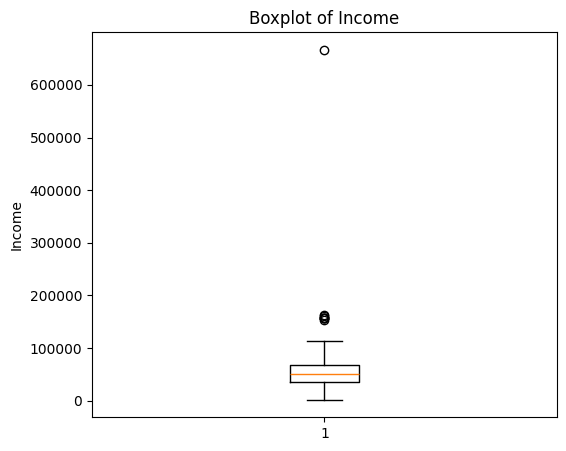

In [ ]:
income = df["Income"].dropna()

print("Số giá trị dùng để vẽ:", len(income))

plt.figure(figsize=(6, 5))
plt.boxplot(income)
plt.title("Boxplot of Income")
plt.ylabel("Income")
plt.show()

- Nhóm outlier mật độ thấp (Khoảng $150,000$ - $170,000$): Có một cụm vài điểm dữ liệu nằm ngay sát phía trên đường whisker. Đây là những khách hàng có thu nhập cao vượt trội so với đại đa số, nhưng vẫn nằm trong phạm vi có thể giải thích được bằng thực tế (nhóm thu nhập cao/thượng lưu).
- Siêu điểm dị biệt (Extreme Outlier ~ $660,000$): Có một điểm dữ liệu duy nhất cô độc nằm tít trên đỉnh đồ thị (gần mức $660,000$). 

kiểm tra outlier = IQR

In [ ]:
Q1 = df["Income"].quantile(0.25)
Q3 = df["Income"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

income_outliers = df[(df.Income < lower_limit) | (df.Income > upper_limit)]

income_outliers

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
164,8475,1973,PhD,Married,157243.0,0,1,01-03-2014,98,20,...,0,0,0,0,0,0,0,3,11,0
617,1503,1976,PhD,Together,162397.0,1,1,03-06-2013,31,85,...,1,0,0,0,0,0,0,3,11,0
655,5555,1975,Graduation,Divorced,153924.0,0,0,07-02-2014,81,1,...,0,0,0,0,0,0,0,3,11,0
687,1501,1982,PhD,Married,160803.0,0,0,04-08-2012,21,55,...,0,0,0,0,0,0,0,3,11,0
1300,5336,1971,Master,Together,157733.0,1,0,04-06-2013,37,39,...,1,0,0,0,0,0,0,3,11,0
1653,4931,1977,Graduation,Together,157146.0,0,0,29-04-2013,13,1,...,1,0,0,0,0,0,0,3,11,0
2132,11181,1949,PhD,Married,156924.0,0,0,29-08-2013,85,2,...,0,0,0,0,0,0,0,3,11,0
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0


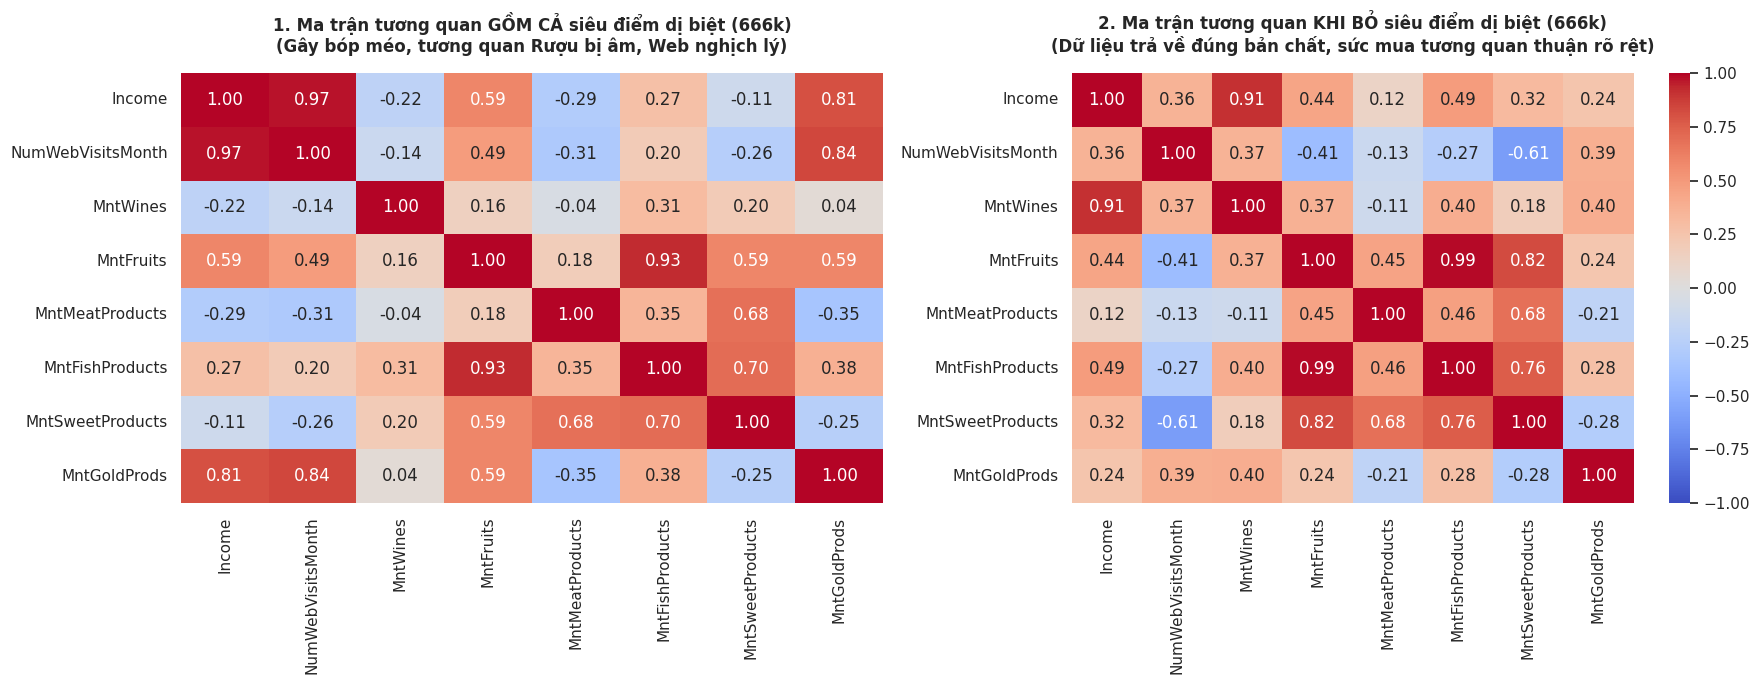

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Xác định danh sách các cột sản phẩm và biến liên quan
product_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cols_to_corr = ['Income', 'NumWebVisitsMonth'] + product_cols

# Đảm bảo các cột này ở dạng số (numeric) để tính tương quan
for col in cols_to_corr:
    if col in income_outliers.columns:
        income_outliers[col] = pd.to_numeric(income_outliers[col], errors='coerce')

# 2. Tách thành 2 tập dữ liệu để chứng minh sự phi lý
# Tập A: Gồm toàn bộ 8 dòng outliers (chứa cả điểm 666k)
corr_with_extreme = income_outliers[cols_to_corr].corr()

# Tập B: Loại bỏ siêu điểm dị biệt 666k (chỉ giữ lại nhóm ~150k)
df_no_extreme = income_outliers[income_outliers['Income'] < 200000]
corr_without_extreme = df_no_extreme[cols_to_corr].corr()

# 3. Tiến hành vẽ biểu đồ so sánh song song
sns.set_theme(style='whitegrid', font='DejaVu Sans') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap 1: Có điểm 666k
sns.heatmap(corr_with_extreme, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", ax=ax1, cbar=False)
ax1.set_title('1. Ma trận tương quan GỒM CẢ siêu điểm dị biệt (666k)\n(Gây bóp méo, tương quan Rượu bị âm, Web nghịch lý)', fontsize=12, fontweight='bold', pad=15)

# Heatmap 2: Đã loại bỏ điểm 666k
sns.heatmap(corr_without_extreme, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", ax=ax2)
ax2.set_title('2. Ma trận tương quan KHI BỎ siêu điểm dị biệt (666k)\n(Dữ liệu trả về đúng bản chất, sức mua tương quan thuận rõ rệt)', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('correlation_comparison.png', dpi=300)

 * Tương quan giữa Income và MntWines (Rượu) là $-0.22$.Tương quan giữa Income và MntMeatProducts (Thịt) là $-0.29$.
 Ý nghĩa phi lý: Về mặt kinh tế, điều này ám chỉ "Khách hàng có thu nhập càng cao thì càng nghèo đi, chi tiêu cho ăn uống và đồ cao cấp càng ít đi". Điều này hoàn toàn đi ngược lại quy luật phân khúc khách hàng thực tế.

[Loại bỏ các đặc trưng không mang thông tin]

ID được loại bỏ vì chỉ đóng vai trò là mã định danh duy nhất cho mỗi khách hàng. Giá trị của cột này không phản ánh bất kỳ đặc điểm nhân khẩu học, hành vi mua sắm hay mức độ tương tác nào của khách hàng, do đó không có giá trị trong việc phân tích hoặc phân cụm.
Z_CostContact và Z_Revenue được loại bỏ vì đây là các thuộc tính hằng số (constant features). Kiểm tra dữ liệu cho thấy:

In [ ]:
print(df["Z_CostContact"].unique())
# [3]

print(df["Z_Revenue"].unique())
# [11]

[3]
[11]


In [ ]:
print(df["Z_CostContact"].nunique())
print(df["Z_Revenue"].nunique())

1
1


Khi phương sai bằng 0, biến không tạo ra bất kỳ khác biệt nào giữa các khách hàng, không đóng góp vào việc tính khoảng cách Euclidean của K-Means, cũng không cung cấp thông tin hữu ích cho PCA hoặc các mô hình học máy khác. Vì vậy hai cột này được loại bỏ khỏi tập dữ liệu trước khi tiếp tục xử lý.

In [ ]:
print(df["Z_CostContact"].var())
print(df["Z_Revenue"].var())

0.0
0.0


In [4]:
df = df.drop(["ID", "Z_CostContact", "Z_Revenue"], axis=1)
df.shape

(2240, 26)

xóa tình trạng hôn nhân bất thường

In [ ]:
df = df[(df["Marital_Status"] != "YOLO") & (df["Marital_Status"] != "Absurd")]

tuổi

tuổi trải dài --> dữ liệu quá khứ nhiều, không có giá trị phân tích, cần loại bỏ cac đội tuổi quá khứ

In [ ]:
print(df["Year_Birth"].describe())

count    2240.000000
mean     1968.805804
std        11.984069
min      1893.000000
25%      1959.000000
50%      1970.000000
75%      1977.000000
max      1996.000000
Name: Year_Birth, dtype: float64


phase 2
feature engerring

- tính thời gian gắn bó 
- tính tuổi
- children = teen+kid

1. thời gian gắn bó
mốc thời gian dữ liệu xét được công bố

In [5]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

last_date = pd.to_datetime("2014-10-04")

df["DaysCustomer"] = (last_date - df["Dt_Customer"]).dt.days
print(df[["DaysCustomer"]].head())
df = df.drop(columns=["Dt_Customer"])

   DaysCustomer
0           760
1           210
2           409
3           236
4           258


2. tính tuổi
năm mốc =2014

In [6]:

min_year = df["Year_Birth"].min()
max_year = df["Year_Birth"].max()

result = df[
    (df["Year_Birth"] == min_year) | 
    (df["Year_Birth"] == max_year)
][["Year_Birth", "Education"]]

print("Năm sinh bé nhất:", min_year)
print("Năm sinh lớn nhất:", max_year)
print(result)

Năm sinh bé nhất: 1893
Năm sinh lớn nhất: 1996
      Year_Birth Education
46          1996  2n Cycle
239         1893  2n Cycle
1170        1996     Basic


In [7]:
# Quy ước: người tốt nghiệp sinh năm 1996 là 25 tuổi
ref_year = 2014

# Tạo cột Age cho toàn bộ dữ liệu theo mốc này
df["Age"] = ref_year - df["Year_Birth"]


Lọc Outlier những người trên 100 tuổi và những người âm tuổi 

In [8]:
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)].reset_index(drop=True)
# Sau khi tạo xong cột tuổi thì drop cột Year_Birth
df.drop(columns=["Year_Birth"], inplace=True)

3. Tạo cột children

In [9]:
df["children"] = df["Kidhome"] + df["Teenhome"]

df = df.drop(columns=["Kidhome", "Teenhome"])

In [ ]:
#kiểm tra shape của dữ liệu sau khi feature engineering
print(df.shape)

(2237, 25)


điền nan income

In [10]:
df["_age_band"] = (df["Age"] // 10) * 10
df["Income"] = df.groupby(["_age_band", "Education"])["Income"].transform(
    lambda s: s.fillna(s.median())
)
df.drop(columns=["_age_band"], inplace=True) 

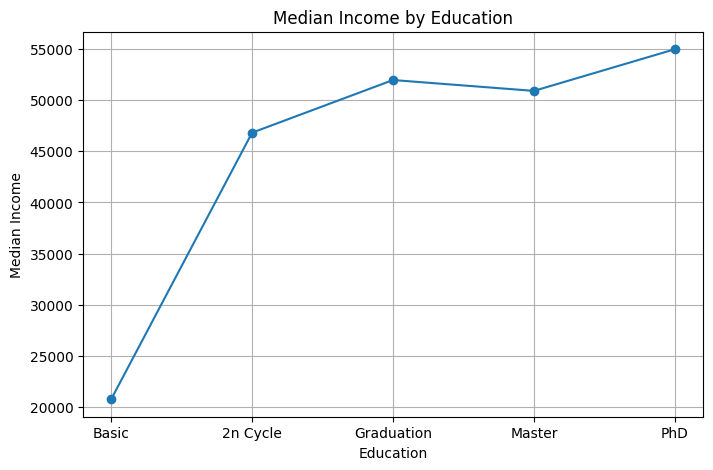

In [ ]:
edu_order = [
    "Basic",
    "2n Cycle",
    "Graduation",
    "Master",
    "PhD"
]

edu_income = (
    df.groupby("Education")["Income"]
      .median()
      .reindex(edu_order)
)

plt.figure(figsize=(8,5))
plt.plot(
    edu_income.index,
    edu_income.values,
    marker="o"
)

plt.title("Median Income by Education")
plt.xlabel("Education")
plt.ylabel("Median Income")
plt.grid(True)

plt.show()

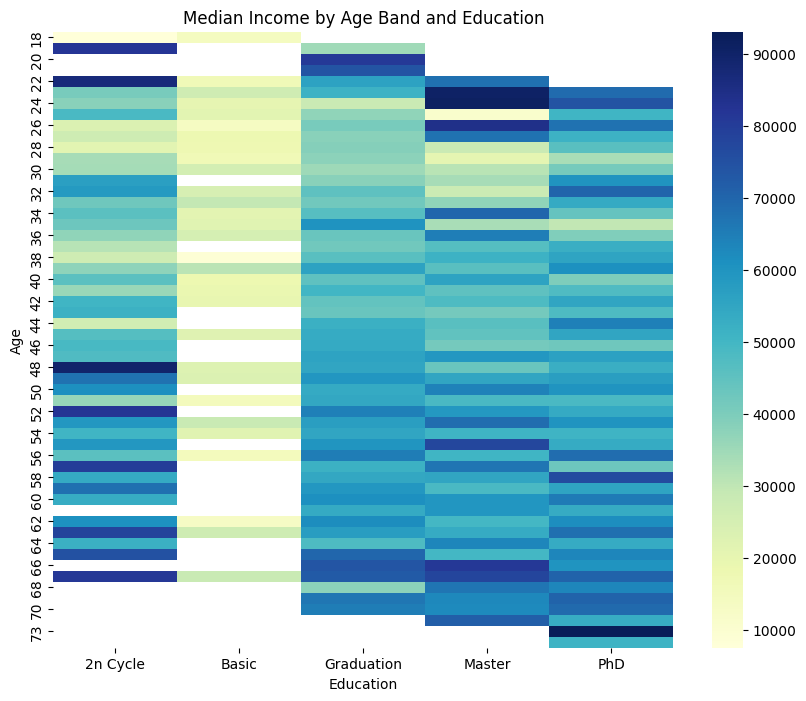

In [ ]:
pivot = pd.pivot_table(
    df,
    values="Income",
    index="Age",
    columns="Education",
    aggfunc="median"
)

import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(
    pivot,
    annot=False,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title(
    "Median Income by Age Band and Education"
)

plt.show()

In [ ]:
# Tạo lại age band để vẽ
df["_age_band"] = (df["Age"] // 10) * 10

pivot = pd.pivot_table(
    df,
    values="Income",
    index="_age_band",
    columns="Education",
    aggfunc="median"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Median Income by Age Band and Education")
plt.xlabel("Education")
plt.ylabel("Age Band")

plt.show()

# Nếu không cần nữa thì xóa
df.drop(columns="_age_band", inplace=True)

In [11]:
df["_age_band"] = (df["Age"] // 10) * 10
df["Income"] = df.groupby(["_age_band", "Education"])["Income"].transform(
    lambda s: s.fillna(s.median())
)
df.drop(columns=["_age_band"], inplace=True) 

kiểm tra dữ liệu sau khi thêm

In [ ]:
print(df.isnull().sum())

Education              0
Marital_Status         0
Income                 0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
DaysCustomer           0
Age                    0
children               0
dtype: int64


[Giai đoạn 4: Mã hóa & Chuẩn hóa] ──► OrdinalEncoder (Học vấn), hôn nhân , StandardScaler

In [18]:
# Encode Education theo thứ tự
edu_order = [["Basic", "Graduation","2n Cycle", "Master", "PhD"]]
df["Education"] = OrdinalEncoder(categories=edu_order).fit_transform(df[["Education"]]).astype(int)

Encode Marital_Status thành mã nhị phân

In [ ]:
# Encode Marital_Status thành 0/1
marital_map = {
    "Married": 1, "Together": 1,
    "Single": 0, "Divorced": 0, "Widow": 0,
    "Alone": 0
}
df["Marital_Status"] = df["Marital_Status"].map(marital_map).astype(int)

In [21]:
# Xuất DataFrame ra file CSV
df.to_csv("customer_analysis_result_before_clustering.csv", index=False, encoding="utf-8-sig")

print("Đã xuất file CSV thành công!")

Đã xuất file CSV thành công!


Kiểm tra sau Encoding

In [20]:
#Kiểm tra sau Encoding
print("Sau khi encode:")
print(df[["Education", "Marital_Status"]].head())
print(df[["Education", "Marital_Status"]].describe())


Sau khi encode:
   Education  Marital_Status
0          1               0
1          1               0
2          1               1
3          1               1
4          4               1
         Education  Marital_Status
count  2237.000000     2237.000000
mean      2.046938        0.645060
std       1.277308        0.478602
min       0.000000        0.000000
25%       1.000000        0.000000
50%       1.000000        1.000000
75%       3.000000        1.000000
max       4.000000        1.000000


* **Chuẩn hóa dữ liệu số (`StandardScaler`):** Đưa toàn bộ các thuộc tính số về cùng một thang đo có $\mu = 0$ và $\sigma = 1$ bằng công thức:



$$z = \frac{x - \mu}{\sigma}$$

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_cols])

df_scaled = pd.DataFrame(X_scaled, columns=numeric_cols)


Thống kê các cột sau khi chuẩn hóa 

In [ ]:
print("Sau khi StandardScaler:")
print(df_scaled.describe().T)

Sau khi StandardScaler:
                      count          mean       std       min       25%  \
Education            2237.0 -1.381699e-16  1.000224 -1.602898 -0.819827   
Marital_Status       2237.0 -1.127594e-16  1.000224 -1.348103 -1.348103   
Income               2237.0  1.143475e-16  1.000224 -2.016168 -0.667127   
MntWines             2237.0  6.352640e-17  1.000224 -0.903407 -0.832084   
MntFruits            2237.0 -6.273232e-17  1.000224 -0.661606 -0.636422   
MntMeatProducts      2237.0 -5.240928e-17  1.000224 -0.739845 -0.668926   
MntFishProducts      2237.0  5.796784e-17  1.000224 -0.686886 -0.631969   
MntSweetProducts     2237.0 -2.223424e-17  1.000224 -0.655663 -0.631440   
MntGoldProds         2237.0  2.699872e-17  1.000224 -0.844859 -0.671924   
NumDealsPurchases    2237.0  1.746976e-17  1.000224 -1.204030 -0.686563   
NumWebPurchases      2237.0  6.987904e-17  1.000224 -1.470819 -0.751094   
NumCatalogPurchases  2237.0  5.399744e-17  1.000224 -0.910939 -0.910939   
N

In [ ]:
# index=False giúp bỏ qua cột chỉ số mặc định của pandas khi ghi vào file
df_scaled .to_csv("customer_personality_preprocessed_outliers.csv", index=False, encoding="utf-8-sig")

In [ ]:
output = pd.read_csv("customer_personality_preprocessed2.csv")
output.head()



,Education,Marital_Status,Income,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,DaysCustomer,Age,children
0,0.0,-1.0,0.205776,0.960417,2.50000,2.217593,3.404255,2.50000,1.361702,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.882184,0.722222,-1.0
1,0.0,-1.0,-0.153874,-0.339583,-0.21875,-0.282407,-0.212766,-0.21875,-0.382979,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.698276,0.888889,1.0
2,0.0,0.0,0.616686,0.525000,1.28125,0.277778,2.106383,0.40625,0.382979,-0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.126437,0.277778,-1.0
3,0.0,0.0,-0.754551,-0.339583,-0.12500,-0.217593,-0.042553,-0.15625,-0.404255,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.623563,-0.777778,0.0
4,1.5,0.0,0.210502,-0.002083,1.09375,0.236111,0.723404,0.59375,-0.191489,1.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.560345,-0.611111,0.0


In [ ]:
# ==========================
# 2. Thông tin cột
# ==========================
print("\n" + "=" * 50)
print("COLUMN INFORMATION")
print("=" * 50)

print(df.info())


COLUMN INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2237 non-null   int64  
 1   Marital_Status       2237 non-null   int64  
 2   Income               2237 non-null   float64
 3   Recency              2237 non-null   str    
 4   MntWines             2237 non-null   int64  
 5   MntFruits            2237 non-null   int64  
 6   MntMeatProducts      2237 non-null   int64  
 7   MntFishProducts      2237 non-null   int64  
 8   MntSweetProducts     2237 non-null   int64  
 9   MntGoldProds         2237 non-null   int64  
 10  NumDealsPurchases    2237 non-null   int64  
 11  NumWebPurchases      2237 non-null   int64  
 12  NumCatalogPurchases  2237 non-null   int64  
 13  NumStorePurchases    2237 non-null   int64  
 14  NumWebVisitsMonth    2237 non-null   int64  
 15  AcceptedCmp3         2237 non